In [1]:
from autocvd import autocvd
autocvd(num_gpus = 1, interval=1)
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '7'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.style.use('./paper.mcstyle')

import time 
from functools import partial  # Change this line - lowercase 'partial'

import jax.numpy as jnp
import jax

from jax import jit

# jax.config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec, NamedSharding         #IMPORT NEEDED FOR AUTOMATIC PARALLELISM
from jax.experimental import shard_map



import pandas as pd
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth



from odisseo import construct_initial_state
from odisseo.dynamics import  DIRECT_ACC_MATRIX, DIRECT_ACC_LAXMAP
from odisseo.option_classes import SimulationConfig, SimulationParams, MNParams, NFWParams, PlummerParams, PSPParams, MN_POTENTIAL, NFW_POTENTIAL, PSP_POTENTIAL, DIFFRAX_BACKEND, TSIT5
from odisseo.initial_condition import Plummer_sphere
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.utils import projection_on_GD1
from astropy import units as u

code_length = 10.0 * u.kpc
code_mass = 1e4 * u.Msun
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  
N_particles = 1000

pos_com_final = jnp.array([[11.8, 0.79, 6.4]]) * u.kpc.to(code_units.code_length)
vel_com_final = jnp.array([[109.5,-254.5,-90.3]]) * (u.km/u.s).to(code_units.code_velocity)

config_sim = SimulationConfig(N_particles = N_particles,
                            return_snapshots = False, 
                            num_timesteps = 1_000, 
                            external_accelerations=(NFW_POTENTIAL, MN_POTENTIAL, PSP_POTENTIAL), 
                            acceleration_scheme = DIRECT_ACC_MATRIX,
                            softening = (0.1 * u.pc).to(code_units.code_length).value,
                            integrator = DIFFRAX_BACKEND,
                             fixed_timestep = False,
                             diffrax_solver = TSIT5,) #default values
        #the center of mass needs to be integrated backwards in time first 
config_com = config_sim._replace(N_particles=1,)

@jit
def run_simulation(rng_key, params):

    params_samples = SimulationParams(t_end = params[0] * u.Gyr.to(code_units.code_time),
                        Plummer_params = PlummerParams(Mtot=params[1] * u.Msun.to(code_units.code_mass),
                                                       a = params[2] * u.kpc.to(code_units.code_length),),
                        NFW_params = NFWParams(Mvir=params[3] * u.Msun.to(code_units.code_mass),
                                               r_s= params[4] * u.kpc.to(code_units.code_length)),
                        MN_params = MNParams(M = params[5] * u.Msun.to(code_units.code_mass),
                                             a = params[6] * u.kpc.to(code_units.code_length),
                                            b = (0.280 * u.kpc).to(code_units.code_length).value),
                        PSP_params= PSPParams(M = 4501365375.06545 * u.Msun.to(code_units.code_mass),
                                                alpha = 1.8, 
                                                r_c = (1.9*u.kpc).to(code_units.code_length).value),  
                        G = code_units.G, )

    params_com = params_samples._replace(t_end=-params_samples.t_end,)
    mass_com = jnp.array([params_samples.Plummer_params.Mtot]) 
    
    #we construmt the initial state of the com 
    initial_state_com = construct_initial_state(pos_com_final, vel_com_final,)
    #we run the simulation backwards in time for the center of mass
    final_state_com = time_integration(initial_state_com, mass_com, config=config_com, params=params_com)
    #we calculate the final position and velocity of the center of mass
    pos_com = final_state_com[:, 0]
    vel_com = final_state_com[:, 1]

    #we construct the initial state of the Plummer sphere
    positions, velocities, mass = Plummer_sphere(key=rng_key, params=params_samples, config=config_sim)
    #we add the center of mass position and velocity to the Plummer sphere particles
    positions = positions + pos_com
    velocities = velocities + vel_com
    #initialize the initial state
    initial_state_stream = construct_initial_state(positions, velocities, )
    #run the simulation
    final_state = time_integration(initial_state_stream, mass, config=config_sim, params=params_samples)

    #projection on the GD1 stream
    stream = projection_on_GD1(final_state, code_units=code_units,)

    return stream

import jax
import jax.numpy as jnp
from jax.typing import ArrayLike
from functools import partial

# In JAX, we don't need a get_device() function.
# JAX automatically uses the best available device (GPU/TPU > CPU).

# To make the code JIT-compilable, we mark static arguments.
# num_runs is a static argument because it controls the shape of an intermediate array
# and the unrolling of loops inside the compiler.
@partial(jax.jit, static_argnames=['num_runs'])
def pokie(key: jax.random.PRNGKey,
          truth: ArrayLike,
          posterior: ArrayLike,
          num_runs: int = 100
          ) -> jnp.ndarray:
    """
    Monte Carlo estimation of predictive probabilities and calibration using JAX.

    Parameters
    ----------
    key : jax.random.PRNGKey
        JAX random key for all stochastic operations.
    truth : Array of shape (T, q)
        Ground-truth parameter vectors (T samples in q dims).
    posterior : Array of shape (M, T, S, q)
        Posterior draws from M models, T truths, S samples each in q dims.
    num_runs : int
        Number of Monte Carlo replications.

    Returns
    -------
    score : Array of shape (M,)
        Pokie Score per model, averaged across runs.
    """
    # JAX arrays are used directly; no device placement needed.
    truth = jnp.asarray(truth)
    posterior = jnp.asarray(posterior)

    # Shapes
    M, T, S, q = posterior.shape
    if truth.shape != (T, q):
        raise ValueError(f"Expected truth shape {(T, q)}, got {tuple(truth.shape)}")

    # Constants
    N = S - 1
    max_val = (N + 1) / (N + 2)

    # --- Define a function for a single Monte Carlo run ---
    def _pokie_single_run(run_key: jax.random.PRNGKey):
        """Computes the score for one Monte Carlo run."""
        # Split the key for different random operations
        key_center, key_radius = jax.random.split(run_key)

        # 1. Random centers (T, q)
        centers = jax.random.uniform(key_center, (T, q))

        # 2. Distances (M, T, S)
        # Broadcasting: posterior(M,T,S,q) - centers(None,T,None,q) -> (M,T,S,q)
        dists = jnp.linalg.norm(posterior - centers[None, :, None, :], axis=3)

        # 3. Random radius per (model, truth)
        rand_idx = jax.random.randint(key_radius, (M, T), 0, S)

        # Use advanced integer indexing to gather the radii
        # This is equivalent to the PyTorch version with m_idx and t_idx
        radii = jnp.take_along_axis(dists, rand_idx[:, :, None], axis=2).squeeze(axis=2)
        radii += 1e-12

        # 4. Truth distances broadcast (M, T)
        true_dists = jnp.linalg.norm(centers - truth, axis=1)  # (T,)
        # k is 1.0 if truth is inside the hypersphere, 0.0 otherwise
        k = (true_dists[None, :] <= radii).astype(jnp.float32)  # (M, T)

        # 5. Counts per radius (M, T)
        # Broadcasting: dists(M,T,S) < radii(M,T,None) -> (M,T,S)
        counts = (dists < radii[:, :, None]).sum(axis=2)

        # 6. Predictive probability (M, T)
        prob_in = (counts + 1) / (N + 2)
        prob_out = (N - counts + 1) / (N + 2)
        prob = prob_in * k + prob_out * (1 - k)

        # 7. Calibration (M, T)
        calib = prob / max_val

        # 8. Aggregate for this run
        return calib.mean(axis=1) # Returns shape (M,)

    # --- Use vmap to run the Monte Carlo simulation in parallel ---
    # Create a unique key for each run
    run_keys = jax.random.split(key, num_runs)

    # vmap the single-run function. This is like a parallel for-loop.
    # It returns an array of shape (num_runs, M)
    total_score = jax.vmap(_pokie_single_run)(run_keys)

    # Average results across runs
    score = total_score.mean(axis=0)

    return score


@partial(jax.jit, static_argnames=['num_bootstrap', 'num_runs'])
def pokie_bootstrap(key: jax.random.PRNGKey,
                      truth: ArrayLike,
                      posterior: ArrayLike,
                      num_bootstrap: int = 100,
                      num_runs: int = 100
                      ) -> jnp.ndarray:
    """
    Bootstrap wrapper for the Pokie score calculation using JAX.

    Parameters
    ----------
    key : jax.random.PRNGKey
        JAX random key for all stochastic operations.
    truth : Array of shape (T, q)
        Ground-truth parameter vectors.
    posterior : Array of shape (M, T, S, q)
        Posterior draws from M models.
    num_bootstrap : int
        Number of bootstrap resamples.
    num_runs : int
        Number of Monte Carlo replications for each Pokie score calculation.

    Returns
    -------
    boot_score : Array of shape (num_bootstrap, M)
        The Pokie score for each bootstrap sample.
    """
    truth = jnp.asarray(truth)
    posterior = jnp.asarray(posterior)
    M, T, S, q = posterior.shape

    # --- Define a function for a single bootstrap iteration ---
    def _bootstrap_iteration(bootstrap_key: jax.random.PRNGKey):
        """Performs one bootstrap resample and calculates the pokie score."""
        # Split key for resampling and for the pokie calculation
        key_resample, key_pokie = jax.random.split(bootstrap_key)

        # Resample with replacement
        idx = jax.random.randint(key_resample, (T,), 0, T)
        truth_bs = truth[idx]
        posterior_bs = posterior[:, idx, :, :]

        # Run pokie on the bootstrapped data
        score = pokie(
            key_pokie,
            truth_bs,
            posterior_bs,
            num_runs=num_runs
        )
        return score

    # --- Use vmap to run all bootstrap iterations in parallel ---
    # Create a unique key for each bootstrap run
    bootstrap_keys = jax.random.split(key, num_bootstrap)

    # vmap the single bootstrap iteration function
    boot_score = jax.vmap(_bootstrap_iteration)(bootstrap_keys)

    return boot_score




In [2]:
# def PPC_data_generetation(data_path, num_posterior_samples=1000):
#     # Load data
#     data = np.load(os.path.join(data_path, 'true_observation_prediction.npz'))
#     truth_data = data['true_theta']
#     posterior_data = data['predicted_theta'][:num_posterior_samples]
#     posterior_data[:, 3] = 10**posterior_data[:, 3]
#     posterior_data[:, 5] = 10**posterior_data[:, 5]

#     key = jax.random.PRNGKey(0)
#     keys = jax.random.split(key, posterior_data.shape[0])
#     run_simulation_lax = lambda x: run_simulation(rng_key=x[0], params=x[1])
#     Posterior_simulation = jax.lax.map(run_simulation_lax, (keys, posterior_data), batch_size=100)
#     key = jax.random.PRNGKey(40000)
#     posterior_mean_simulation = run_simulation(key,  jnp.mean(posterior_data, axis=0))
#     return Posterior_simulation, truth_data, posterior_mean_simulation

# Posterior_simulation, truth_data, posterior_mean_simulation = PPC_data_generetation('../logs/OdisseoCrossAttentionSetTransformer_onehead_3layers_128_AllParameters_Position_uniforprior_2e5_TSIT5_error/pictures/', num_posterior_samples=10_000)

# np.savez('./PPC_data.npz', Posterior_simulation=Posterior_simulation, truth_data=truth_data, posterior_mean_simulation=posterior_mean_simulation)

In [23]:
from matplotlib.ticker import MaxNLocator
from chainconsumer import PlotConfig

def PPC(Posterior_simulation, truth_data, posterior_mean_simulation, data_path):
    
    key = jax.random.PRNGKey(500000)
    sim_true = truth_data
    sim_true = jnp.array(sim_true)
    sim_true = run_simulation(key, sim_true )
    sim_true_mean = jnp.mean(sim_true, axis=0)
    labels = [r'$r [kpc]$', r'$\phi_1 [deg]$', r'$\phi_2 [deg]$', r'$v_r [km/s]$', "$v_{\phi_1}\cos(\phi_2)$\n$[mas/yr]$", "$v_{\phi_2}$\n$[mas/yr]$", ]
    
    

    print('Mean of the posterior simulation')
    posterior_simualtion_mean = np.mean(Posterior_simulation, axis=1)
    df = pd.DataFrame(posterior_simualtion_mean, columns=labels)
    df = df.astype(float)
    df = df.dropna()
    # Convert to float and handle any non-numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.empty:
        # If no numeric columns, convert all to float
        numeric_df = df.astype(float)
    # Create corner plot with ChainConsumer
    # c = ChainConsumer()
    # c.set_plot_config(PlotConfig(max_ticks=3,
    #                              tick_font_size=14,
    #                              label_font_size=20,
    #                              summarise=False,))

    # c.add_chain(Chain(samples=numeric_df, name="PPC", ), )    
    # c.add_truth(Truth(location={
    #         '$r$': sim_true_mean[0],
    #         '$\phi_1$': sim_true_mean[1],
    #         '$\phi_2$': sim_true_mean[2],
    #         '$v_r$': sim_true_mean[3],
    #         '$v_{\phi_1}\cos(\phi_2)$': sim_true_mean[4],
    #         '$v_{\phi_2}$': sim_true_mean[5],}))
    # fig = c.plotter.plot()   

    # plt.show()

    # print('Posterior Simulation Countour')

    df = pd.DataFrame(Posterior_simulation.reshape(-1, 6), columns=labels)
    df = df.astype(float)
    df = df.dropna()
    # Convert to float and handle any non-numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.empty:
        # If no numeric columns, convert all to float
        numeric_df = df.astype(float)
    # Create corner plot with ChainConsumer
    c = ChainConsumer()
    c.add_chain(Chain(samples=numeric_df, 
                      name=r"$S(\theta_{\text{Posterior}})$", 
                      shade=False,
                      bar_shade=False,
                      color='black',
                      linewidth=2,), )

    df_true = pd.DataFrame(sim_true, columns=labels)
    c.add_chain(Chain(samples=df_true,
                       name=r"$S(\theta_{\text{True}})$",
                       color='red',
                       shade=False,
                       bar_shade=False,
                       linewidth=2,), )
    c.set_plot_config(PlotConfig(max_ticks=3,
                                 tick_font_size=17,
                                 label_font_size=35,
                                 summarise=False,
                                 ))
    fig = c.plotter.plot()  
    fig.savefig('./PPC_cornerplot.pdf', bbox_inches='tight') 

    plt.show()


    print('Posterior Mean simulation')
    # posterior_mean_simulation = run_simulation(key,  jnp.mean(posterior_data, axis=0))
    posterior_mean_R = posterior_mean_simulation[:, 0]
    posterior_mean_phi1 = posterior_mean_simulation[:, 1]
    posterior_mean_phi2 = posterior_mean_simulation[:, 2]
    posterior_mean_vR = posterior_mean_simulation[:, 3]
    posterior_mean_v1_cosphi2 = posterior_mean_simulation[:, 4]
    posterior_mean_v2 = posterior_mean_simulation[:, 5]

    true_R = sim_true[:, 0]
    true_phi1 = sim_true[:, 1]
    true_phi2 = sim_true[:, 2]
    true_vR = sim_true[:, 3]
    true_v1_cosphi2 = sim_true[:, 4]
    true_v2 = sim_true[:, 5]

    fig = plt.figure(figsize=(25, 5), tight_layout=True, )
    size=10
    ax = fig.add_subplot(131)
    ax.scatter(posterior_mean_phi1, posterior_mean_phi2, s=size, label=r'$\mathcal{S}(\hat{\theta})$', color='black')
    ax.scatter(true_phi1, true_phi2, s=size, label=r'$\theta_{True}$', color='red')
    ax.set_xlabel("$\phi_1 [deg]$", fontsize=45)
    ax.set_ylabel("$\phi_2 [deg]$", fontsize=45)
     # Set exactly 4 ticks on both axes for density plots
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)
    ax.tick_params(axis='both', labelsize=20)
    ax.set_xlim(-120, 70)
    ax.set_ylim(-8, 2)
    

    ax = fig.add_subplot(132)
    ax.scatter(posterior_mean_v1_cosphi2,posterior_mean_v2,
                s=size, label=r'$\mathcal{S}(\hat{\theta})$', color='black')
    ax.scatter(true_v1_cosphi2, true_v2, s=size, label=r'$\theta_{True}$', color='red')
    ax.set_xlabel("$v_{\phi_1}\cos(\phi_2) [mas/yr]$", fontsize=45)
    ax.set_ylabel("$v_{\phi_2} [mas/yr]$", fontsize=45)
     # Set exactly 4 ticks on both axes for density plots
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)
    ax.tick_params(axis='both', labelsize=20)
    ax.set_xlim(-2., 1.0)
    ax.set_ylim(-0.10, 0.10)

    ax = fig.add_subplot(133)
    ax.scatter(posterior_mean_R, posterior_mean_vR, s=size, label=r'$\mathcal{S}(<\theta_{\text{Posterior}}>)$', color='black',)
    ax.scatter(true_R, true_vR, s=size, label=r'$S(\theta_{True})$', color='red')
    ax.set_xlabel(r"$r [kpc]$", fontsize=45)
    ax.set_ylabel(r"$v_r [km/s]$", fontsize=45)
     # Set exactly 4 ticks on both axes for density plots
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)
    ax.tick_params(axis='both', labelsize=20)
    ax.set_xlim(6, 20)
    ax.set_ylim(-250, 250)
    ax.legend(fontsize=20)


    plt.savefig('./PPC_scatterplots.pdf', bbox_inches='tight')
    plt.show()


    # print('Density map difference')

    # def density_map(x, y, bins, ranges):
    #     H, xedges, yedges = np.histogram2d(x, y, bins=bins, range=ranges)
    #     return H.T, xedges, yedges  # transpose for imshow

    # # bins and ranges
    # bins = 25

    # ranges1 = [[-120, 70], [-8, 2]]
    # H_true1, xe1, ye1 = density_map(true_phi1, true_phi2, bins, ranges1)
    # H_sim1, _, _ = density_map(posterior_mean_phi1, posterior_mean_phi2, bins, ranges1)
    # res1 = H_true1 - H_sim1

    # ranges2 = [[-2.0, 1.0], [-0.10, 0.10]]
    # H_true2, xe2, ye2 = density_map(true_v1_cosphi2, true_v2, bins, ranges2)
    # H_sim2, _, _ = density_map(posterior_mean_v1_cosphi2, posterior_mean_v2, bins, ranges2)
    # res2 = H_true2 - H_sim2

    # ranges3 = [[6, 20], [-250, 250]]
    # H_true3, xe3, ye3 = density_map(true_R, true_vR, bins, ranges3)
    # H_sim3, _, _ = density_map(posterior_mean_R, posterior_mean_vR, bins, ranges3)
    # res3 = H_true3 - H_sim3

    # # collect all
    # datasets = [
    #     (H_true1, H_sim1, res1, xe1, ye1, "$\phi_1$ [deg]", "$\phi_2$ [deg]"),
    #     (H_true2, H_sim2, res2, xe2, ye2, "$v_{\phi_1}\cos(\phi_2)$ [mass/yr]", "$v_{\phi_2}$ [mass/yr]"),
    #     (H_true3, H_sim3, res3, xe3, ye3, "r [kpc]", "$v_r$ [km/s]"),
    # ]

    # titles = ["True density", "Sim density", "Residual (True - Sim)"]

    # fig, axes = plt.subplots(3, 3, figsize=(9, 7), constrained_layout=True)

    # for j, (H_true, H_sim, res, xe, ye, xlabel, ylabel) in enumerate(datasets):
    #     # common min/max for densities
    #     vmin = 0
    #     vmax = max(H_true.max(), H_sim.max())
    #     # symmetric for residuals
    #     resmax = np.abs(res).max()
        
    #     for i, (H, cmap, vmin_i, vmax_i) in enumerate([
    #         (H_true, "Greys", vmin, vmax),   # grayscale
    #         (H_sim, "Greys", vmin, vmax),    # grayscale
    #         (res, "RdBu_r", -resmax, resmax) # residuals
    #     ]):
    #         ax = axes[j, i]
    #         im = ax.imshow(
    #             H,
    #             origin="lower",
    #             extent=[xe[0], xe[-1], ye[0], ye[-1]],
    #             aspect="auto",
    #             cmap=cmap,
    #             vmin=vmin_i, vmax=vmax_i
    #         )
            
    #         # Titles only on top row
    #         if j == 0:
    #             ax.set_title(titles[i], fontsize=16)
            
    #         # Y-labels only for left column
    #         if i == 0:
    #             ax.set_ylabel(ylabel, fontsize=14)
    #         else:
    #             ax.set_ylabel("")
    #             ax.set_yticks([])
            
    #         # X-labels only for bottom row
    #         if j == len(datasets)-1:
    #             ax.set_xlabel(xlabel, fontsize=14)
    #         else:
    #             ax.set_xlabel("")
    #             ax.set_xticks([])
            
    #         fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # plt.show()

    data_allTestset = np.load(os.path.join(data_path, 'predicted_theta_test_set.npz'))
    truth_data = data_allTestset['true_theta']
    posterior_data = data_allTestset['predicted_theta']

    print('Pookie score')    
    print('Truth shape:', truth_data.shape)
    print('Posterior shape:', posterior_data.shape)
    M = 1   # Number of models
    T = truth_data.shape[0]  # Number of ground truth parameters
    S = posterior_data.shape[0] # Number of posterior samples
    q = truth_data.shape[1]  # Dimension of parameters

    posterior_data = np.expand_dims(posterior_data.reshape(T, S, q), axis=0)


    print(f"Truth shape: {truth_data.shape}")

    # --- Run pokie ---
    print("Running pokie...")
    key, pokie_key = jax.random.split(key)
    # The first run will be slower due to JIT compilation
    score = pokie(pokie_key, truth_data, posterior_data, num_runs=100)
    print("Pokie scores per model:", score)
    print("Shape of scores:", score.shape)
    assert score.shape == (M,)
    print("-" * 20)

    # --- Run pokie_bootstrap ---
    print("Running pokie_bootstrap...")
    key, bootstrap_key = jax.random.split(key)
    # The first run will be slower due to JIT compilation
    boot_scores = pokie_bootstrap(
        bootstrap_key,
        truth_data,
        posterior_data,
        num_bootstrap=50,
        num_runs=100
    )
    print("Shape of bootstrap scores:", boot_scores.shape)
    assert boot_scores.shape == (50, M)
    # We can now compute statistics like confidence intervals
    lower, upper = jnp.percentile(boot_scores, jnp.array([2.5, 97.5]), axis=0)
    print("\nMean bootstrap scores:", boot_scores.mean(axis=0))
    print("95% CI (lower):", lower)
    print("95% CI (upper):", upper)

Mean of the posterior simulation


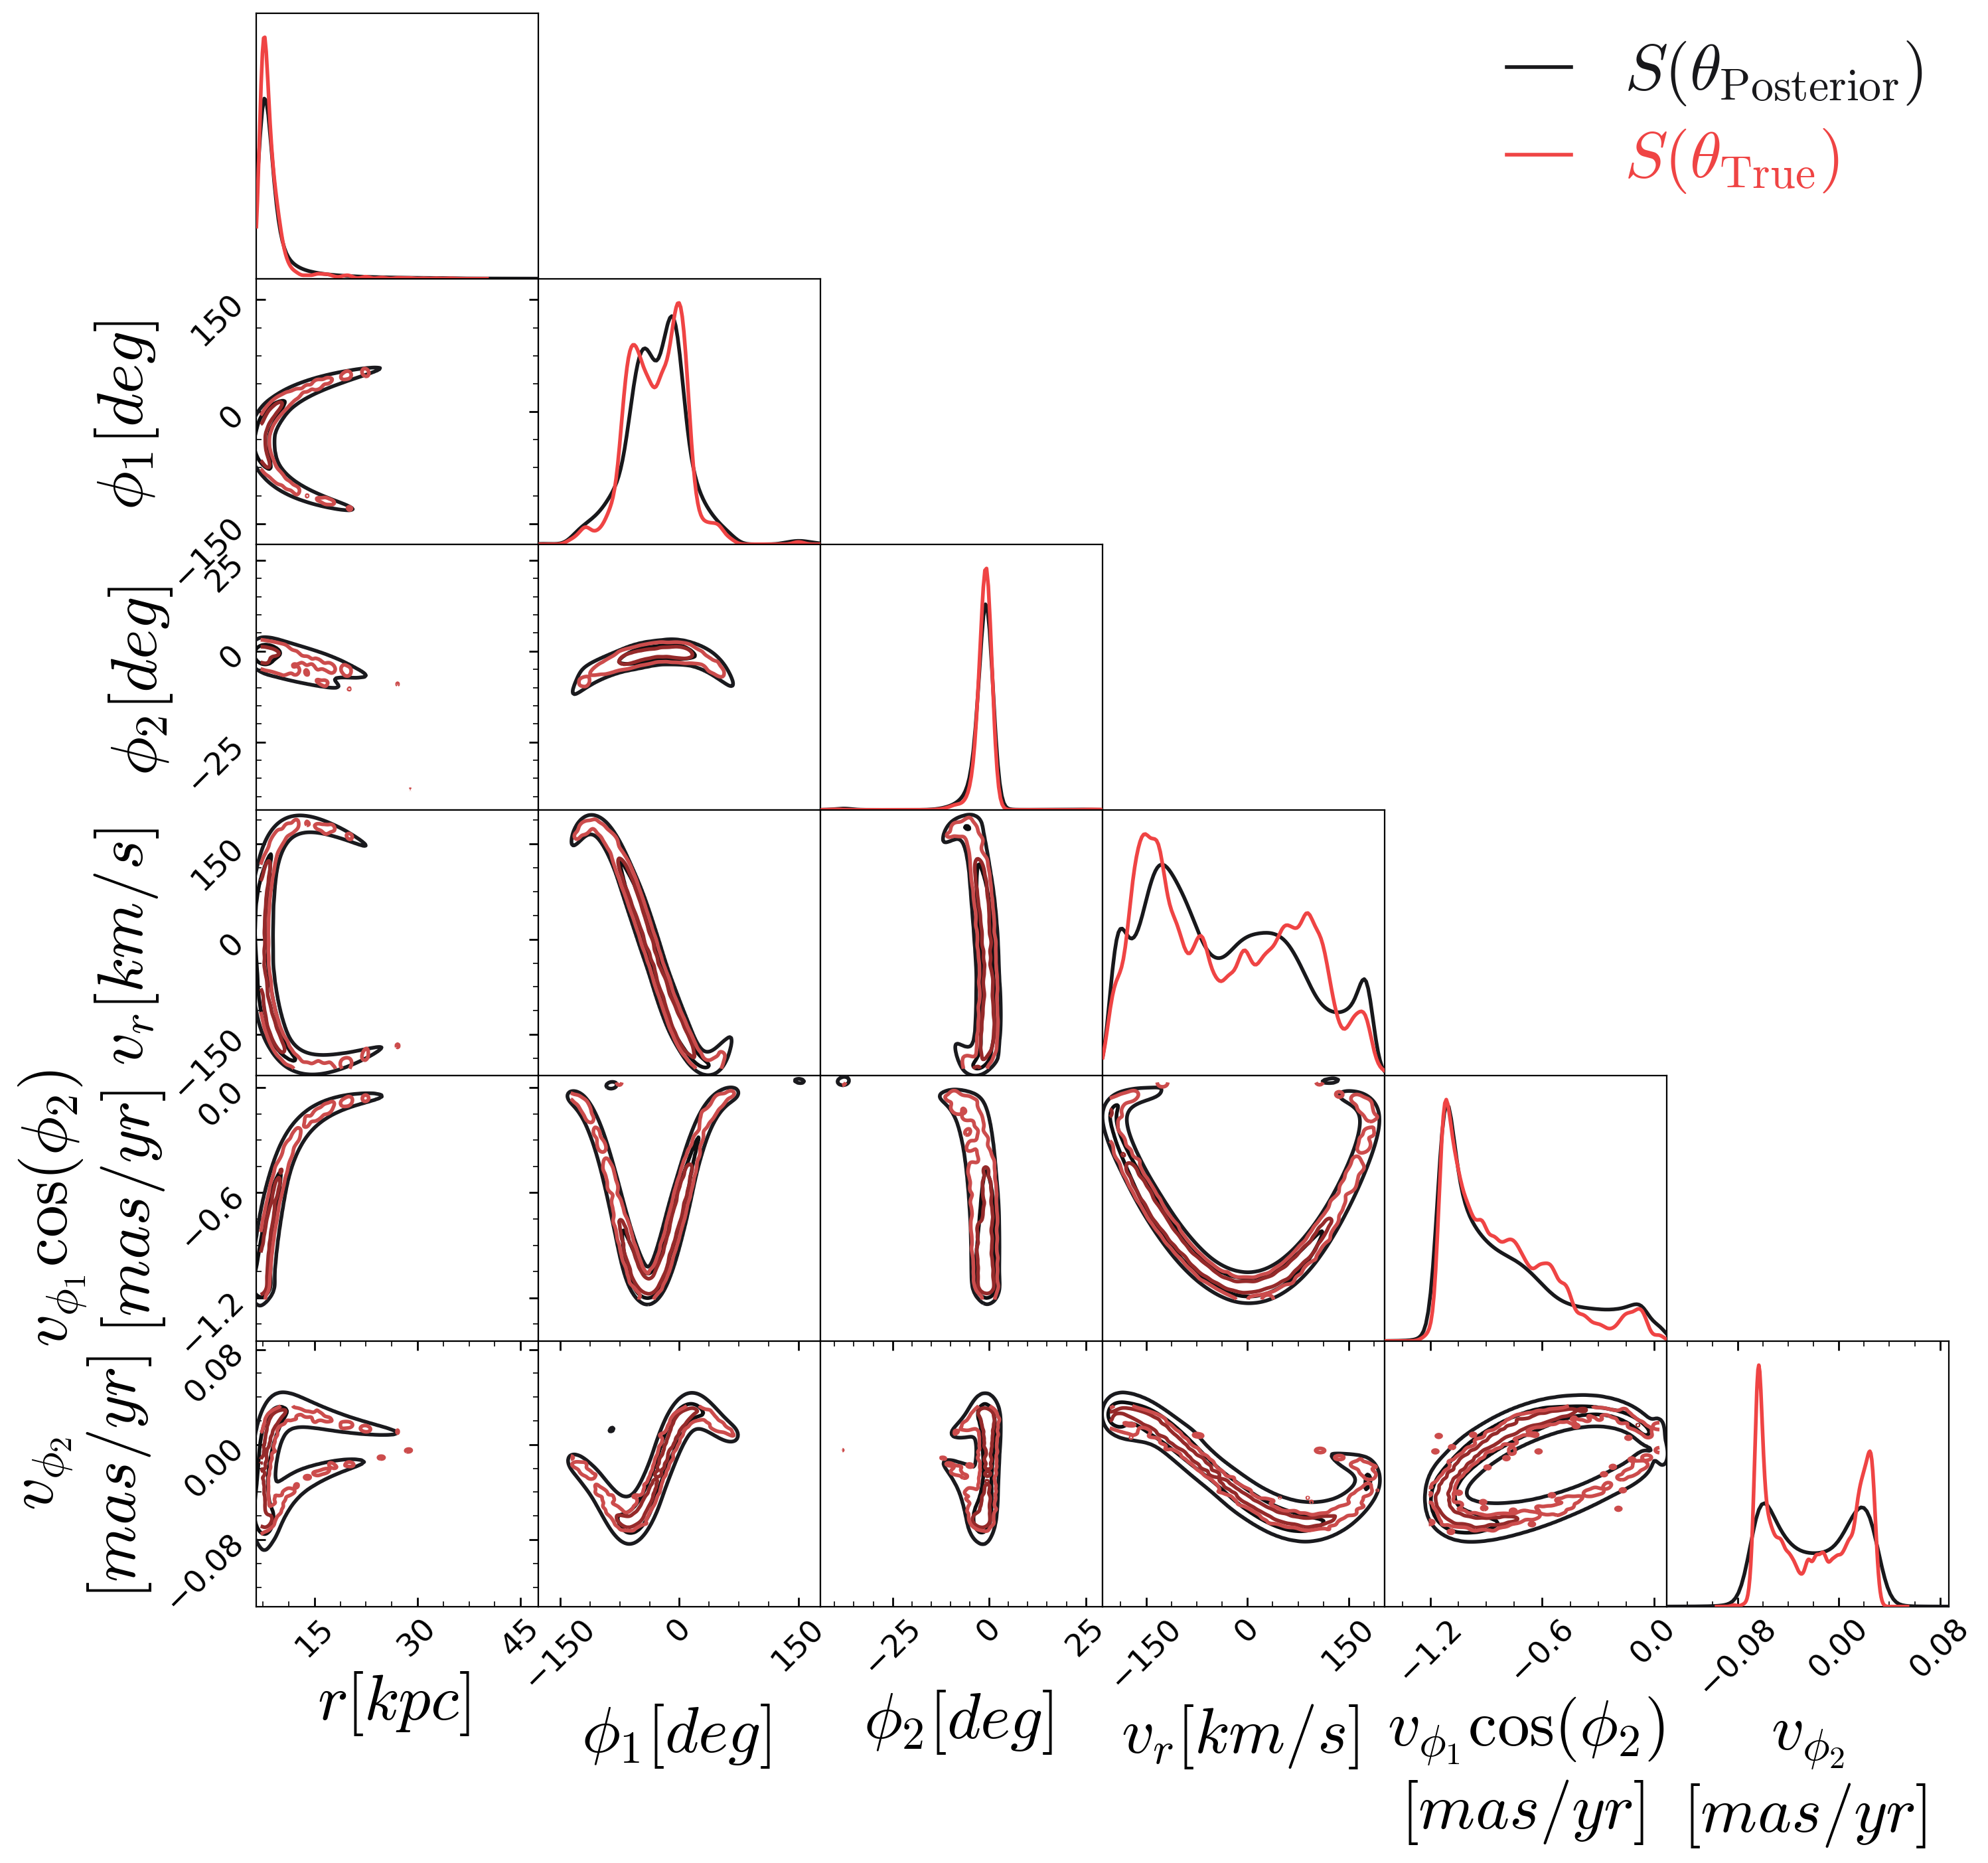

Posterior Mean simulation


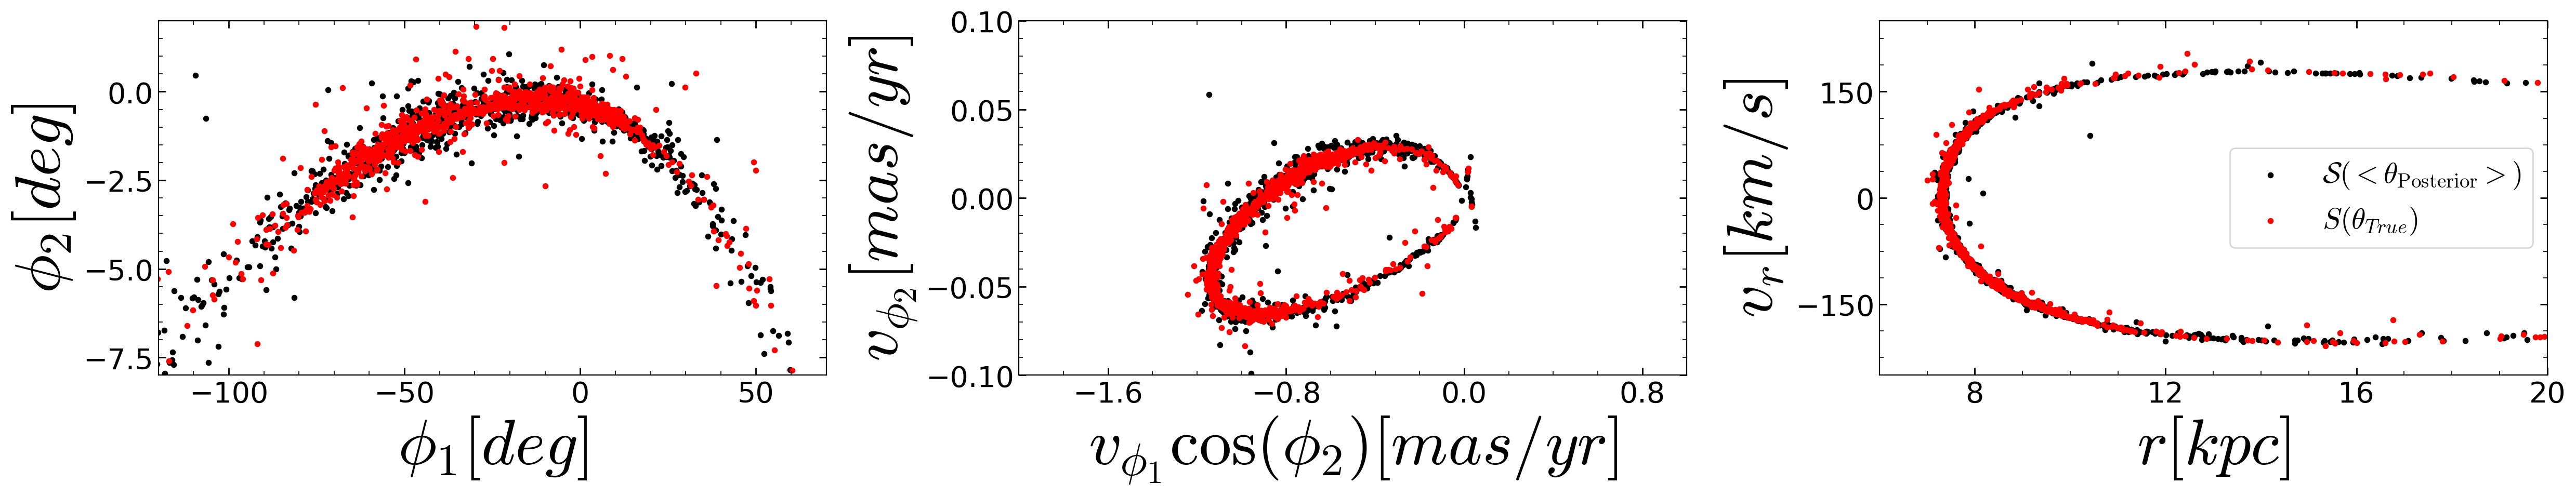

FileNotFoundError: [Errno 2] No such file or directory: '../logs/OdisseoCrossAttentionSetTransformer_onehead_3layers_128_AllParameters_Position_uniforprior_2e5_TSIT5_error/pictures/predicted_theta_test_set.npz'

In [24]:
Posterior_simulation = np.load('./PPC_data.npz')['Posterior_simulation']
truth_data = np.load('./PPC_data.npz')['truth_data']
posterior_mean_simulation = np.load('./PPC_data.npz')['posterior_mean_simulation']

PPC(Posterior_simulation=Posterior_simulation, 
    truth_data=truth_data, 
    posterior_mean_simulation=posterior_mean_simulation, 
    data_path = '../logs/OdisseoCrossAttentionSetTransformer_onehead_3layers_128_AllParameters_Position_uniforprior_2e5_TSIT5_error/pictures/' )

In [ ]:
# from astropy.table import Table
# ### load in data from Starkman+2024 (you will need to change this directory to your own file location!)
# table = Table.read('gd1_membership_likelhoods_init.ecsv', format='ascii.ecsv')
# ### Cut at 75% or greater membership probability
# gd1_table = table[table['allstream (MLE)']>=0.75]
# ra_rad, dec_rad = jnp.deg2rad(gd1_table['coord'].ra.value), jnp.deg2rad(gd1_table['coord'].dec.value)

FileNotFoundError: [Errno 2] No such file or directory: 'gd1_membership_likelhoods_init.ecsv'